# Student Math Score Prediction

This is my first data science project. I used the "Students Performance in Exams" dataset from Kaggle, which has 1,000 students and 8 columns. I wanted to find out what affects math scores and whether I could build a model to predict them.

## What I did
1. Loaded the data with pandas and checked it. There were no missing values.
2. Made a histogram of math scores. Most students scored around 66, and the graph looked like a bell shape.
3. Compared groups to see what makes a difference.
4. Trained a Linear Regression model with scikit-learn to predict math scores.

## What I found
- Students who completed the test prep course scored about 5.6 points higher in math (69.7 vs 64.1).
- Students whose parents have a master's degree scored higher than students whose parents finished only high school (69.7 vs 62.1).

## My models
- **Model 1** (using all columns, including reading and writing scores): average error of 4.2 points, R2 = 0.88.
- **Model 2** (using only background info, no reading or writing scores): average error of 11.3 points, R2 = 0.18.

## What I learned
Reading and writing scores helped a lot in predicting math, because students who are good in one subject are often good in the others. Background info like parents' education and test prep matters a little, but it doesn't explain most of the difference. I also learned that a pattern in the data doesn't mean one thing causes the other.

## Tools used
Python, pandas, matplotlib, scikit-learn. Built with AI assistance while learning.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv


In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv")
print(df.shape)
df.head()

(1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


df.info()

In [3]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


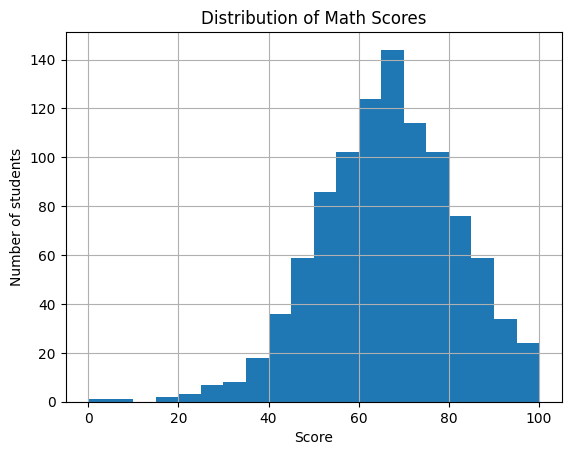

In [4]:
import matplotlib.pyplot as plt

df["math score"].hist(bins=20)
plt.title("Distribution of Math Scores")
plt.xlabel("Score")
plt.ylabel("Number of students")
plt.show()

In [5]:
df.groupby("test preparation course")["math score"].mean()

test preparation course
completed    69.695531
none         64.077882
Name: math score, dtype: float64

In [6]:
df.groupby("parental level of education")["math score"].mean().sort_values()

parental level of education
high school           62.137755
some high school      63.497207
some college          67.128319
associate's degree    67.882883
bachelor's degree     69.389831
master's degree       69.745763
Name: math score, dtype: float64

In [7]:
df.groupby("test preparation course")["math score"].mean()

test preparation course
completed    69.695531
none         64.077882
Name: math score, dtype: float64

In [8]:
X = pd.get_dummies(df.drop("math score", axis=1), drop_first=True)
y = df["math score"]
X.head()

,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,78,75,True,False,True,False,False,False,False,False,True,False,True,True


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(800, 14) (200, 14)


In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = model.predict(X_test)
print("Average error (points):", mean_absolute_error(y_test, pred))
print("R2 score:", r2_score(y_test, pred))

Average error (points): 4.214763142474851
R2 score: 0.8804332983749565


In [12]:
X2 = pd.get_dummies(df.drop(["math score", "reading score", "writing score"], axis=1), drop_first=True)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)
pred2 = model2.predict(X2_test)

print("Average error (points):", mean_absolute_error(y2_test, pred2))
print("R2 score:", r2_score(y2_test, pred2))

Average error (points): 11.269872775277623
R2 score: 0.17599998338251166
